In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 5000

zones = ['residential', 'commercial', 'industrial', 'park', 'transport']
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df = pd.DataFrame({
    'hour': np.random.randint(0, 24, n),
    'day_of_week': np.random.choice(days, n),
    'zone_type': np.random.choice(zones, n),
    'traffic_density': np.random.uniform(0, 100, n),
    'nearby_events': np.random.randint(0, 5, n),
    'temperature': np.random.uniform(15, 40, n),
    'wind_speed': np.random.uniform(0, 30, n),
})

# Simulate realistic noise levels based on features
df['noise_db'] = (
    40
    + df['hour'].apply(lambda h: 15 if 7 <= h <= 22 else 0)
    + df['zone_type'].map({'residential':0,'park':-5,'commercial':10,'transport':15,'industrial':20})
    + df['traffic_density'] * 0.3
    + df['nearby_events'] * 3
    + np.random.normal(0, 3, n)
).clip(30, 110)

df.to_csv('../data/noise_data.csv', index=False)
print("Dataset created!", df.shape)
df.head()

Dataset created! (5000, 8)


,hour,day_of_week,zone_type,traffic_density,nearby_events,temperature,wind_speed,noise_db
0,6,Tuesday,transport,31.505650,3,23.149948,15.939313,71.399790
1,19,Tuesday,transport,54.188017,1,28.547024,1.640192,86.388607
2,14,Tuesday,park,9.124484,1,19.255366,28.582398,58.805998
3,10,Thursday,industrial,67.894542,3,15.555516,23.776117,107.822202
4,7,Wednesday,park,72.509602,4,23.424578,4.472937,82.144487


In [2]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Basic Stats ===")
print(df.describe().round(2))
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   hour             5000 non-null   int32  
 1   day_of_week      5000 non-null   str    
 2   zone_type        5000 non-null   str    
 3   traffic_density  5000 non-null   float64
 4   nearby_events    5000 non-null   int32  
 5   temperature      5000 non-null   float64
 6   wind_speed       5000 non-null   float64
 7   noise_db         5000 non-null   float64
dtypes: float64(4), int32(2), str(2)
memory usage: 351.4 KB
None

=== Basic Stats ===
          hour  traffic_density  nearby_events  temperature  wind_speed  \
count  5000.00          5000.00        5000.00      5000.00     5000.00   
mean     11.50            50.06           1.99        27.76       14.80   
std       6.99            29.07           1.41         7.23        8.54   
min       0.00             0.02       

C:\Users\rayan\AppData\Local\Temp\ipykernel_11576\3173821121.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='zone_type', y='noise_db', ax=axes[0,0], palette='Set2')


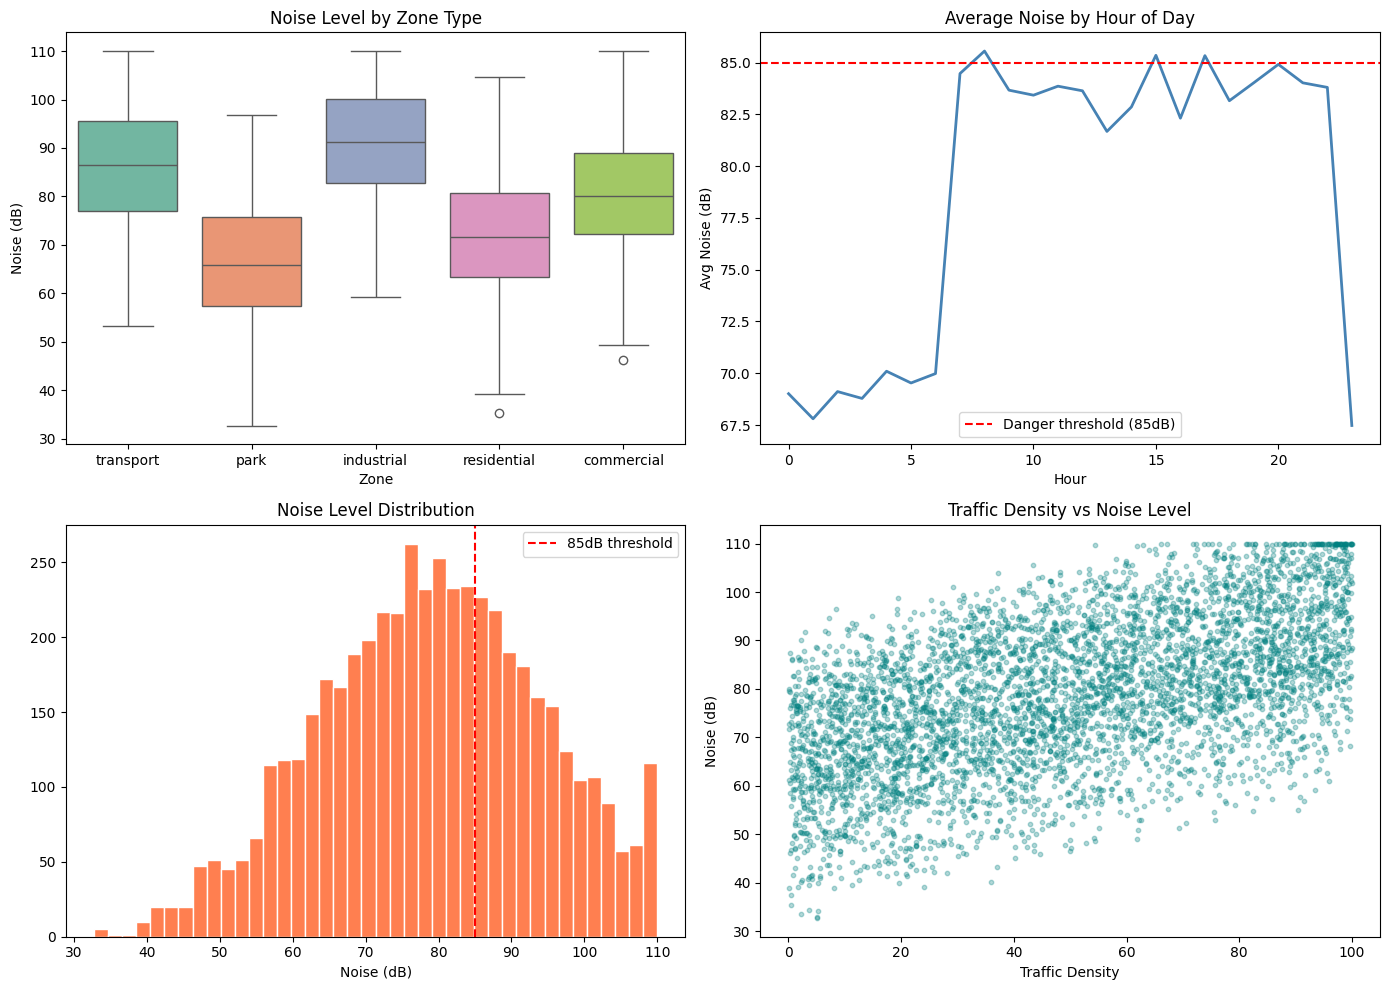

Plots saved!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Noise by zone
sns.boxplot(data=df, x='zone_type', y='noise_db', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Noise Level by Zone Type')
axes[0,0].set_xlabel('Zone'); axes[0,0].set_ylabel('Noise (dB)')

# Noise by hour
hourly = df.groupby('hour')['noise_db'].mean()
axes[0,1].plot(hourly.index, hourly.values, color='steelblue', linewidth=2)
axes[0,1].axhline(85, color='red', linestyle='--', label='Danger threshold (85dB)')
axes[0,1].set_title('Average Noise by Hour of Day')
axes[0,1].set_xlabel('Hour'); axes[0,1].set_ylabel('Avg Noise (dB)')
axes[0,1].legend()

# Noise distribution
axes[1,0].hist(df['noise_db'], bins=40, color='coral', edgecolor='white')
axes[1,0].axvline(85, color='red', linestyle='--', label='85dB threshold')
axes[1,0].set_title('Noise Level Distribution')
axes[1,0].set_xlabel('Noise (dB)'); axes[1,0].legend()

# Traffic vs Noise
axes[1,1].scatter(df['traffic_density'], df['noise_db'], alpha=0.3, color='teal', s=10)
axes[1,1].set_title('Traffic Density vs Noise Level')
axes[1,1].set_xlabel('Traffic Density'); axes[1,1].set_ylabel('Noise (dB)')

plt.tight_layout()
plt.savefig('../data/exploration_plots.png', dpi=150)
plt.show()
print("Plots saved!")